In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

archive_dir = Path("ArchiveUserTraj")
if not archive_dir.exists():
    archive_dir = Path(
        r"C:\Users\wongb\user_trajectories_winter\494-user-trajectories\students\benedict\spring\ArchiveUserTraj"
    )

user_month = pl.read_parquet(archive_dir / "user_month_actions_aggregated.parquet")
panel      = pl.read_parquet(archive_dir / "user_month_actions_panel_classified.parquet")

MONTHLY_STATES = [
    "single_note_writer",
    "single_digit_writer",
    "double_digit_writer",
    "single_note_rater",
    "single_digit_rater",
    "double_digit_rater",
    "single_post_requestor",
    "single_digit_requestor",
    "double_digit_requestor",
    "not_active",
]

LIFETIME_STATES = [
    "single_note_writer",
    "single_digit_writer",
    "double_digit_writer",
    "triple_digit_writer",
    "quad_digit_plus_writer",
    "single_note_rater",
    "single_digit_rater",
    "double_digit_rater",
    "triple_digit_rater",
    "quad_digit_plus_rater",
    "single_post_requestor",
    "single_digit_requestor",
    "double_digit_requestor",
    "triple_digit_requestor",
    "quad_digit_plus_requestor",
    "not_active",
]

# Colour palettes
MONTHLY_COLORS = {
    "single_note_writer":    "#d4e6f1",
    "single_digit_writer":   "#7fb3d3",
    "double_digit_writer":   "#2980b9",
    "single_note_rater":     "#d5f5e3",
    "single_digit_rater":    "#7dcea0",
    "double_digit_rater":    "#27ae60",
    "single_post_requestor": "#fdf2d0",
    "single_digit_requestor":"#f8c471",
    "double_digit_requestor":"#e67e22",
    "not_active":            "#d5dbdb",
}

LIFETIME_COLORS = {
    "single_note_writer":       "#d4e6f1",
    "single_digit_writer":      "#7fb3d3",
    "double_digit_writer":      "#2980b9",
    "triple_digit_writer":      "#1a5276",
    "quad_digit_plus_writer":   "#0b2a3d",
    "single_note_rater":        "#d5f5e3",
    "single_digit_rater":       "#7dcea0",
    "double_digit_rater":       "#27ae60",
    "triple_digit_rater":       "#1a7a3b",
    "quad_digit_plus_rater":    "#0b3d1d",
    "single_post_requestor":    "#fdf2d0",
    "single_digit_requestor":   "#f8c471",
    "double_digit_requestor":   "#e67e22",
    "triple_digit_requestor":   "#a04000",
    "quad_digit_plus_requestor":"#5a1e00",
    "not_active":               "#d5dbdb",
}

print("user_month:", user_month.shape)
print("panel:", panel.shape)


user_month: (92281, 6)
panel: (294573, 17)


In [2]:
# Sum each action type across all months per user
lifetime = (
    user_month.group_by("participantId")
    .agg([
        pl.col("notesWritten").sum().alias("totalWritten"),
        pl.col("notesRated").sum().alias("totalRated"),
        pl.col("notesRequested").sum().alias("totalRequested"),
    ])
)

# Extended classification: same priority (writer > rater > requestor > inactive)
# with additional 3-digit (100-999) and 4-digit+ (>=1000) bins
lifetime_classified = lifetime.with_columns(
    pl.when(pl.col("totalWritten") >= 1000).then(pl.lit("quad_digit_plus_writer"))
    .when(pl.col("totalWritten") >= 100).then(pl.lit("triple_digit_writer"))
    .when(pl.col("totalWritten") >= 10).then(pl.lit("double_digit_writer"))
    .when(pl.col("totalWritten") >= 2).then(pl.lit("single_digit_writer"))
    .when(pl.col("totalWritten") == 1).then(pl.lit("single_note_writer"))
    .when(pl.col("totalRated") >= 1000).then(pl.lit("quad_digit_plus_rater"))
    .when(pl.col("totalRated") >= 100).then(pl.lit("triple_digit_rater"))
    .when(pl.col("totalRated") >= 10).then(pl.lit("double_digit_rater"))
    .when(pl.col("totalRated") >= 2).then(pl.lit("single_digit_rater"))
    .when(pl.col("totalRated") == 1).then(pl.lit("single_note_rater"))
    .when(pl.col("totalRequested") >= 1000).then(pl.lit("quad_digit_plus_requestor"))
    .when(pl.col("totalRequested") >= 100).then(pl.lit("triple_digit_requestor"))
    .when(pl.col("totalRequested") >= 10).then(pl.lit("double_digit_requestor"))
    .when(pl.col("totalRequested") >= 2).then(pl.lit("single_digit_requestor"))
    .when(pl.col("totalRequested") == 1).then(pl.lit("single_post_requestor"))
    .otherwise(pl.lit("not_active"))
    .alias("lifetime_class")
)

lifetime_classified.head()


participantId,totalWritten,totalRated,totalRequested,lifetime_class
str,u32,u32,u32,str
"""BC355A567A64EAC289D7E668B0C516…",0,0,7,"""single_digit_requestor"""
"""CFF553DC46026A5C319E6106E33F4E…",0,6,1,"""single_digit_rater"""
"""4639A68FB696C046F8B79AA90770F9…",0,0,1,"""single_post_requestor"""
"""0C2AC45EB8CC10DE3A3889B2646D91…",1,97,1,"""single_note_writer"""
"""06F13C02E003621882118553AA1B1D…",0,0,1,"""single_post_requestor"""


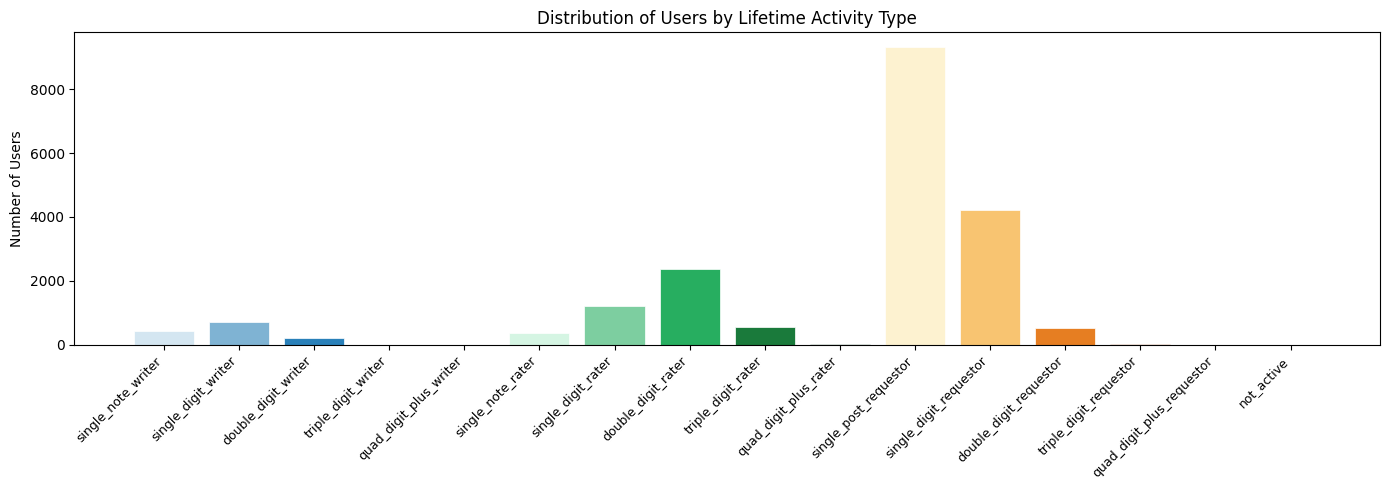

In [3]:
counts_lt = (
    lifetime_classified.group_by("lifetime_class")
    .len()
    .rename({"len": "count"})
)

order_lt = pl.DataFrame({
    "lifetime_class": LIFETIME_STATES,
    "order": list(range(len(LIFETIME_STATES)))
})
counts_lt_ord = (
    order_lt.join(counts_lt, on="lifetime_class", how="left")
    .with_columns(pl.col("count").fill_null(0))
    .sort("order")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    counts_lt_ord["lifetime_class"].to_list(),
    counts_lt_ord["count"].to_list(),
    color=[LIFETIME_COLORS[c] for c in counts_lt_ord["lifetime_class"].to_list()],
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xticks(range(len(LIFETIME_STATES)))
ax.set_xticklabels(LIFETIME_STATES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Users by Lifetime Activity Type")
plt.tight_layout()
plt.show()


In [4]:
# For each user, take the activity_class at their earliest userMonth
first_month_class = (
    panel.sort(["participantId", "userMonth"])
    .group_by("participantId")
    .agg(pl.col("activity_class").first().alias("first_month_class"))
)

print("First-month type distribution:")
print(
    first_month_class.group_by("first_month_class")
    .len()
    .sort("len", descending=True)
)


First-month type distribution:
shape: (8, 2)
┌────────────────────────┬───────┐
│ first_month_class      ┆ len   │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ single_post_requestor  ┆ 11918 │
│ single_note_rater      ┆ 3887  │
│ single_digit_requestor ┆ 2209  │
│ single_digit_rater     ┆ 1590  │
│ double_digit_rater     ┆ 280   │
│ double_digit_requestor ┆ 60    │
│ single_note_writer     ┆ 35    │
│ single_digit_writer    ┆ 21    │
└────────────────────────┴───────┘


In [12]:
# Build user-level mapping: first_month_class -> lifetime_class
user_roles = (
    first_month_class.join(
        lifetime_classified.select(["participantId", "lifetime_class"]),
        on="participantId",
        how="inner",
    )
)

flow = (
    user_roles.group_by(["first_month_class", "lifetime_class"])
    .len()
    .rename({"len": "count"})
)

# Determine which source states actually appear
src_states_present = [
    s for s in MONTHLY_STATES if s in flow["first_month_class"].to_list()
]

# One Sankey + one probability pie per first-month type
for src_state in src_states_present:
    flow_src = flow.filter(pl.col("first_month_class") == src_state)

    if flow_src.height == 0:
        continue

    # Keep lifetime targets in canonical order
    tgt_states = [
        t for t in LIFETIME_STATES if t in flow_src["lifetime_class"].to_list()
    ]

    counts_by_target = {row["lifetime_class"]: row["count"] for row in flow_src.to_dicts()}
    values = [counts_by_target.get(t, 0) for t in tgt_states]

    all_labels = [f"1st: {src_state}"] + [f"Life: {t}" for t in tgt_states]

    # With one source node, links go from node 0 to each target node
    link_src = [0] * len(tgt_states)
    link_tgt = list(range(1, len(tgt_states) + 1))
    link_val = values
    link_col = [MONTHLY_COLORS.get(src_state, "#cccccc")] * len(tgt_states)

    node_colors = [MONTHLY_COLORS.get(src_state, "#cccccc")] + [
        LIFETIME_COLORS.get(t, "#cccccc") for t in tgt_states
    ]

    fig_sankey = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=12,
            thickness=16,
            label=all_labels,
            color=node_colors,
        ),
        link=dict(source=link_src, target=link_tgt, value=link_val, color=link_col),
    ))

    total_users = int(sum(values))
    fig_sankey.update_layout(
        title_text=f"User Role Flow: {src_state} -> Lifetime Classification (n={total_users})",
        font_size=11,
        height=520,
    )
    fig_sankey.show()

    # Pie chart of empirical transition probabilities for this first-month class
    # Group classes below 1% probability into an "Other (<1%)" slice to reduce label stacking
    pie_labels = []
    pie_values = []
    pie_colors = []
    other_count = 0

    for t, v in zip(tgt_states, values):
        p = (v / total_users) if total_users > 0 else 0.0
        if p < 0.01:
            other_count += v
        else:
            pie_labels.append(t)
            pie_values.append(v)
            pie_colors.append(LIFETIME_COLORS.get(t, "#cccccc"))

    if other_count > 0:
        pie_labels.append("Other (<1%)")
        pie_values.append(other_count)
        pie_colors.append("#b0b0b0")

    fig_pie = go.Figure(
        go.Pie(
            labels=pie_labels,
            values=pie_values,
            marker=dict(colors=pie_colors),
            textinfo="label+percent",
            hovertemplate="Lifetime class=%{label}<br>Users=%{value}<br>Probability=%{percent}<extra></extra>",
            sort=False,
        )
    )
    fig_pie.update_layout(
        title_text=f"Empirical Transition Probabilities: {src_state} -> Lifetime Classes (n={total_users})",
        height=520,
    )
    fig_pie.show()


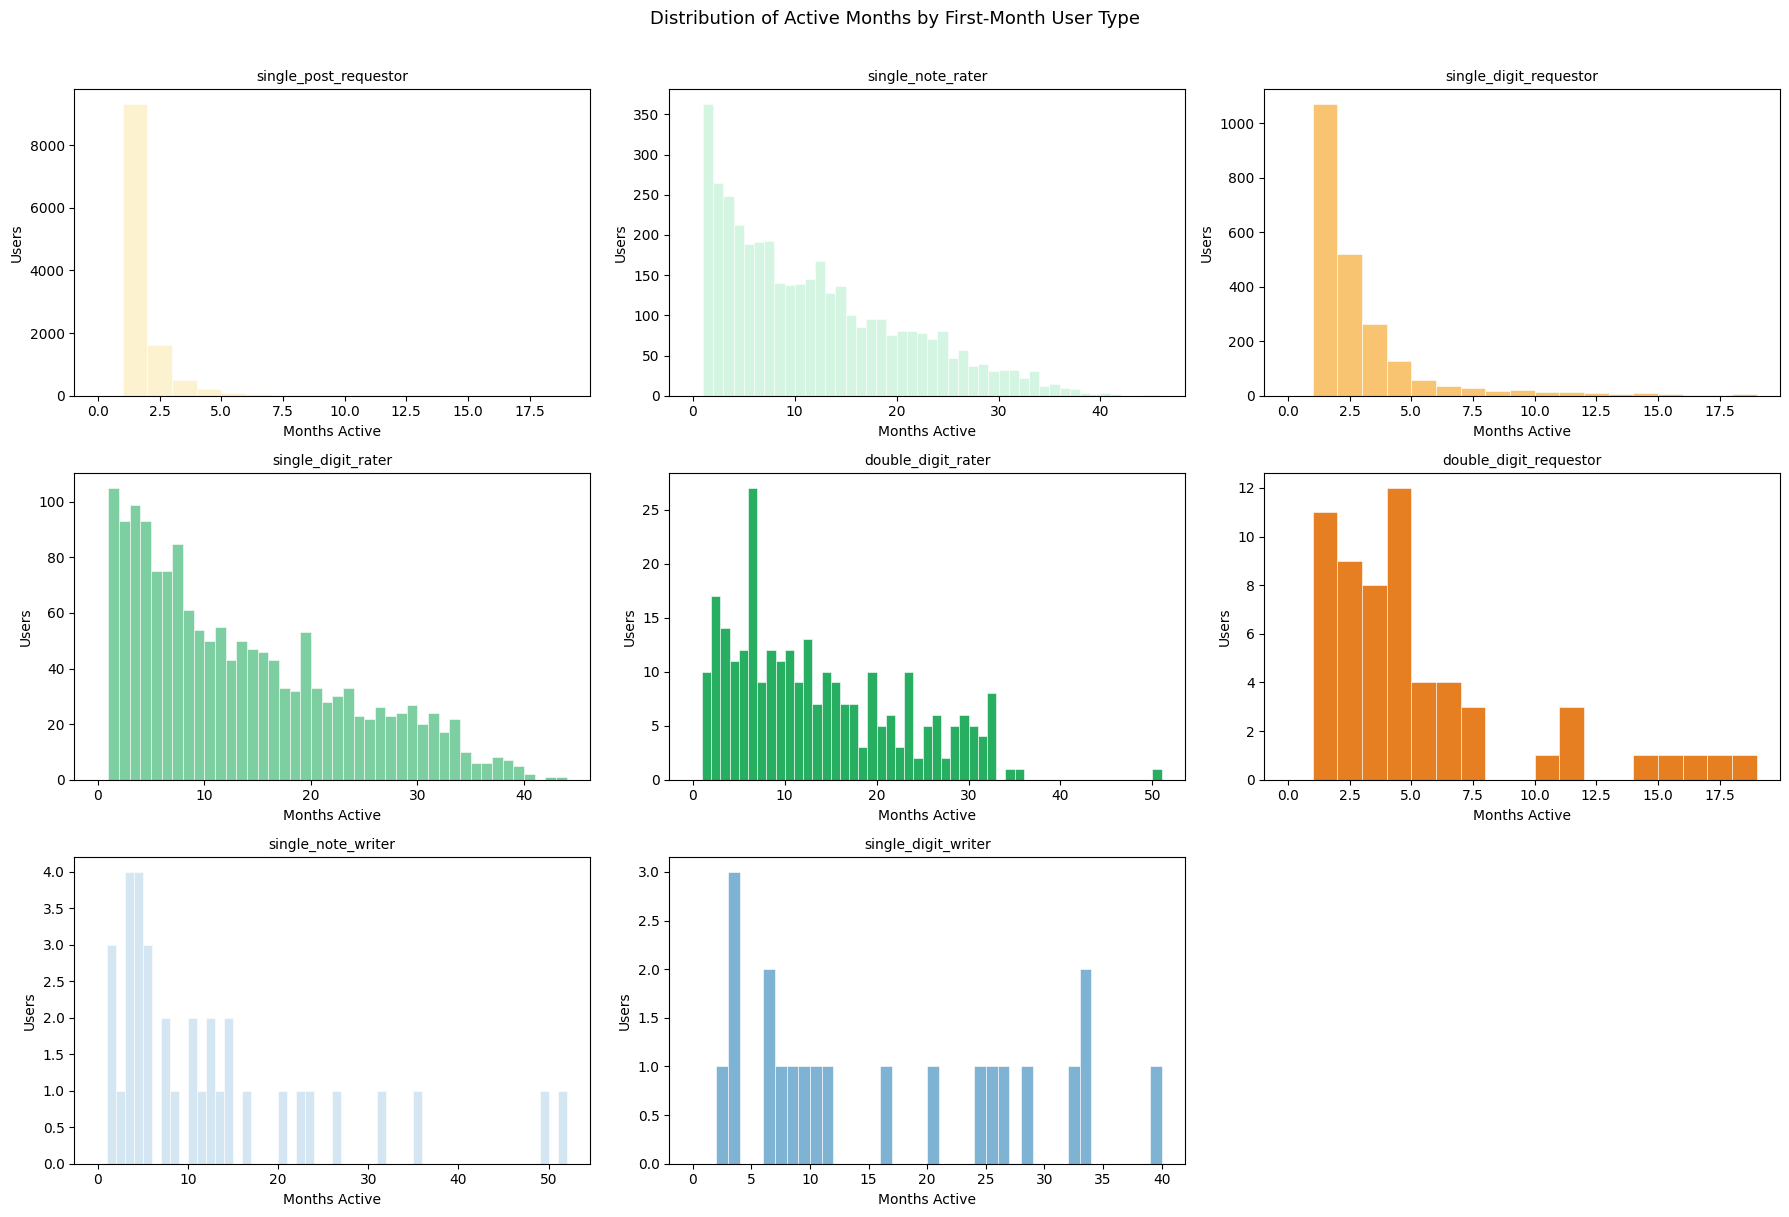

In [6]:
# Count non-inactive months per user
active_months = (
    panel.filter(pl.col("activity_class") != "not_active")
    .group_by("participantId")
    .len()
    .rename({"len": "active_months"})
)

# Join with first-month type
hist_df = (
    first_month_class.join(active_months, on="participantId", how="left")
    .with_columns(pl.col("active_months").fill_null(0))
)

first_types_present = (
    hist_df.group_by("first_month_class")
    .len()
    .sort("len", descending=True)["first_month_class"]
    .to_list()
)

n = len(first_types_present)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).flatten() if n > 1 else [axes]

for i, ftype in enumerate(first_types_present):
    subset = hist_df.filter(pl.col("first_month_class") == ftype)["active_months"].to_numpy()
    axes[i].hist(subset, bins=range(0, int(subset.max()) + 2), color=MONTHLY_COLORS.get(ftype, "#cccccc"),
                 edgecolor="white", linewidth=0.4)
    axes[i].set_title(ftype, fontsize=10)
    axes[i].set_xlabel("Months Active")
    axes[i].set_ylabel("Users")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of Active Months by First-Month User Type", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [7]:
# Compute mode: sort by count desc within each user, take top class
dominant_type = (
    panel.group_by(["participantId", "activity_class"])
    .len()
    .sort(["participantId", "len"], descending=[False, True])
    .group_by("participantId")
    .agg(pl.col("activity_class").first().alias("dominant_type"))
)

# Also compute active months (for stratification later)
dominant_df = (
    dominant_type.join(active_months.with_columns(
        pl.col("active_months").cast(pl.Int64)), on="participantId", how="left")
    .with_columns(pl.col("active_months").fill_null(0))
)

print("Dominant type distribution:")
print(
    dominant_df.group_by("dominant_type")
    .len()
    .sort("len", descending=True)
)


Dominant type distribution:
shape: (10, 2)
┌────────────────────────┬───────┐
│ dominant_type          ┆ len   │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ not_active             ┆ 17803 │
│ single_digit_rater     ┆ 782   │
│ single_post_requestor  ┆ 639   │
│ double_digit_rater     ┆ 352   │
│ single_digit_requestor ┆ 315   │
│ single_note_rater      ┆ 68    │
│ double_digit_requestor ┆ 23    │
│ single_digit_writer    ┆ 9     │
│ single_note_writer     ┆ 8     │
│ double_digit_writer    ┆ 1     │
└────────────────────────┴───────┘


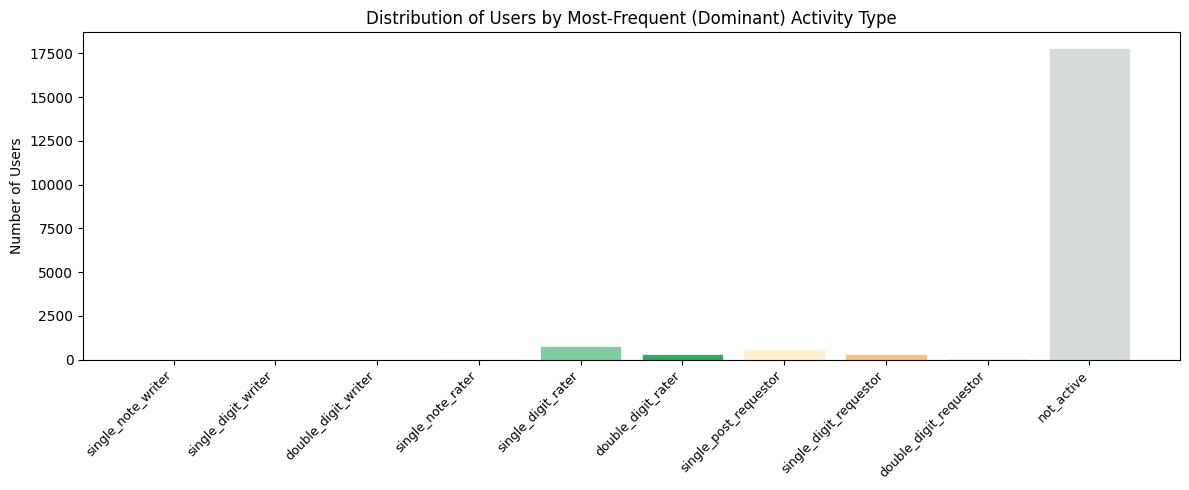

In [8]:
dom_counts = (
    dominant_df.group_by("dominant_type")
    .len()
    .rename({"len": "count"})
)

order_mon = pl.DataFrame({
    "dominant_type": MONTHLY_STATES,
    "order": list(range(len(MONTHLY_STATES)))
})
dom_counts_ord = (
    order_mon.join(dom_counts, on="dominant_type", how="left")
    .with_columns(pl.col("count").fill_null(0))
    .sort("order")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    dom_counts_ord["dominant_type"].to_list(),
    dom_counts_ord["count"].to_list(),
    color=[MONTHLY_COLORS[c] for c in dom_counts_ord["dominant_type"].to_list()],
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xticks(range(len(MONTHLY_STATES)))
ax.set_xticklabels(MONTHLY_STATES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Users by Most-Frequent (Dominant) Activity Type")
plt.tight_layout()
plt.show()


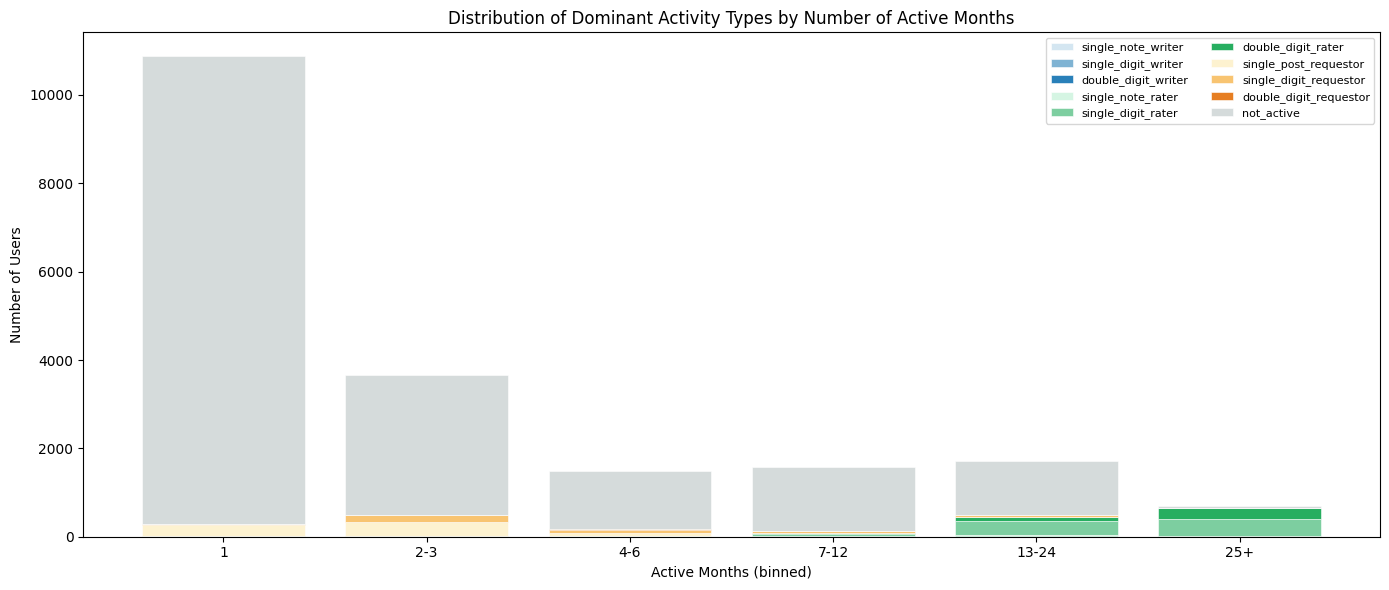

In [9]:
# Bin active months: 1, 2-3, 4-6, 7-12, 13-24, 25+
def month_bin(n):
    if n == 1:
        return "1"
    elif n <= 3:
        return "2-3"
    elif n <= 6:
        return "4-6"
    elif n <= 12:
        return "7-12"
    elif n <= 24:
        return "13-24"
    else:
        return "25+"

BIN_ORDER = ["1", "2-3", "4-6", "7-12", "13-24", "25+"]

dom_binned = dominant_df.with_columns(
    pl.col("active_months").map_elements(month_bin, return_dtype=pl.String).alias("month_bin")
)

# Count users of each dominant type within each active-month bin
strat = (
    dom_binned.group_by(["month_bin", "dominant_type"])
    .len()
    .rename({"len": "count"})
)

# Pivot: rows = bins, cols = dominant types
strat_pivot = (
    pl.DataFrame({"month_bin": BIN_ORDER})
    .join(
        pl.DataFrame({"dominant_type": MONTHLY_STATES}).join(
            pl.DataFrame({"month_bin": BIN_ORDER}), how="cross"
        ),
        on="month_bin", how="left"
    )
    .join(strat, on=["month_bin", "dominant_type"], how="left")
    .with_columns(pl.col("count").fill_null(0))
    .sort(pl.col("month_bin").cast(pl.Enum(BIN_ORDER)))
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(BIN_ORDER))
bottom = np.zeros(len(BIN_ORDER))

for dtype in MONTHLY_STATES:
    vals = []
    for b in BIN_ORDER:
        row = strat_pivot.filter(
            (pl.col("month_bin") == b) & (pl.col("dominant_type") == dtype)
        )
        vals.append(row["count"].item() if row.height > 0 else 0)
    vals = np.array(vals, dtype=float)
    ax.bar(x, vals, bottom=bottom, label=dtype,
           color=MONTHLY_COLORS[dtype], edgecolor="white", linewidth=0.4)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(BIN_ORDER, fontsize=10)
ax.set_xlabel("Active Months (binned)")
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Dominant Activity Types by Number of Active Months")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


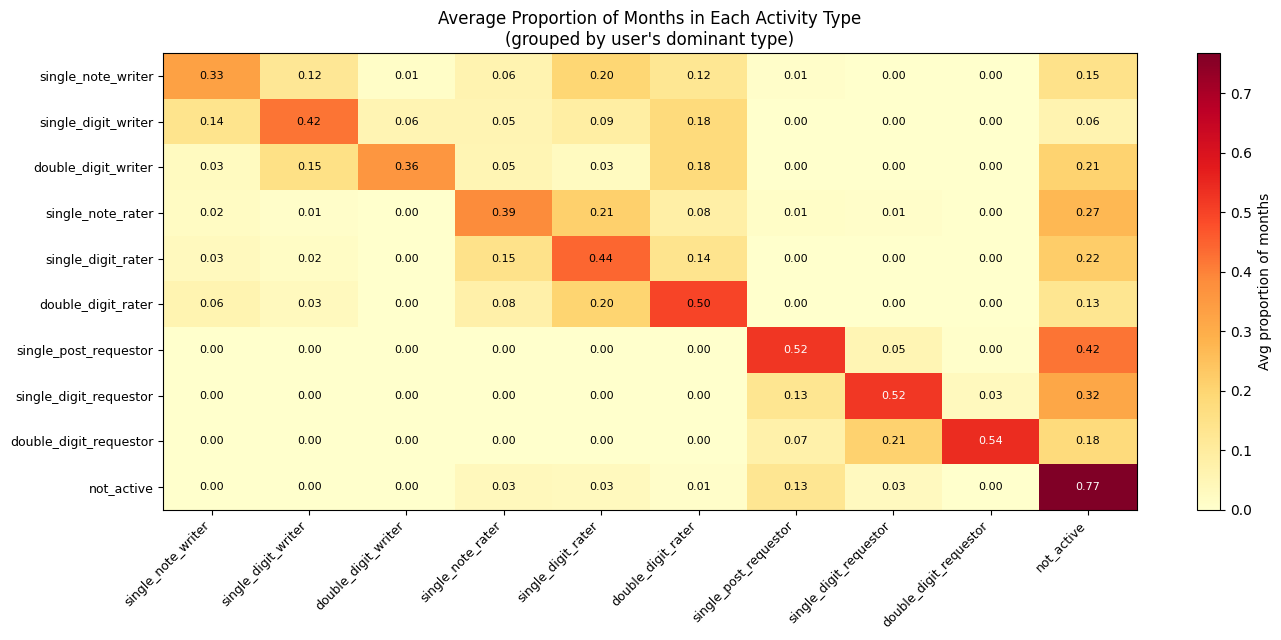

In [10]:
# Proportion of months each user spends in each activity class
total_months_per_user = panel.group_by("participantId").len().rename({"len": "total_months"})

state_counts_per_user = (
    panel.group_by(["participantId", "activity_class"])
    .len()
    .rename({"len": "state_count"})
    .join(total_months_per_user, on="participantId")
    .with_columns(
        (pl.col("state_count") / pl.col("total_months")).alias("proportion")
    )
    .select(["participantId", "activity_class", "proportion"])
)

# Pivot to wide: one row per user, one col per state
proportions_wide = (
    state_counts_per_user.pivot(
        index="participantId",
        on="activity_class",
        values="proportion",
        aggregate_function="sum",
    )
    .fill_null(0.0)
)

# Ensure all 10 state cols exist
for s in MONTHLY_STATES:
    if s not in proportions_wide.columns:
        proportions_wide = proportions_wide.with_columns(pl.lit(0.0).alias(s))

# Join with dominant type
prop_with_dom = proportions_wide.join(
    dominant_type, on="participantId", how="left"
)

# Average proportions by dominant type
avg_props = (
    prop_with_dom.group_by("dominant_type")
    .agg([pl.col(s).mean().alias(s) for s in MONTHLY_STATES])
    .sort("dominant_type")
)

# Reorder rows to canonical state order (only rows that exist)
dom_types_present = [s for s in MONTHLY_STATES if s in avg_props["dominant_type"].to_list()]
avg_props_ord = avg_props.filter(pl.col("dominant_type").is_in(dom_types_present))
order_map = {s: i for i, s in enumerate(MONTHLY_STATES)}
avg_props_ord = avg_props_ord.with_columns(
    pl.col("dominant_type").map_elements(lambda x: order_map.get(x, 99), return_dtype=pl.Int32).alias("_o")
).sort("_o").drop("_o")

mat = avg_props_ord.select(MONTHLY_STATES).to_numpy()
row_labels = avg_props_ord["dominant_type"].to_list()

fig, ax = plt.subplots(figsize=(14, max(4, len(row_labels) * 0.55 + 1)))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0)
plt.colorbar(im, ax=ax, label="Avg proportion of months")
ax.set_xticks(range(len(MONTHLY_STATES)))
ax.set_xticklabels(MONTHLY_STATES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.5 else "black")
ax.set_title("Average Proportion of Months in Each Activity Type\n(grouped by user's dominant type)")
plt.tight_layout()
plt.show()
